# Lesson 7: Factorial Designs, Interactions, and ANCOVA

**Course:** hypothesis_testing_and_statistical_inference  
**Prerequisites:** Basic Python and descriptive statistics

This lesson follows a repeatable workflow: define the question, encode the design,
check assumptions, estimate the effect, quantify uncertainty, test the claim, and
communicate both statistical and practical meaning.


## Learning objectives

1. Interpret an interaction before interpreting main effects
2. Fit a two-factor model and test model terms
3. Use ANCOVA to improve precision while checking slope homogeneity
4. Explain why post-treatment covariate adjustment can bias results


## Setup

Run this cell first. Every example uses a fixed random seed so results are reproducible.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline")
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Work whether the kernel starts in the course root or a level folder.
working_dir = Path.cwd()
COURSE_ROOT = working_dir if (working_dir / "data").exists() else working_dir.parent
DATA_DIR = COURSE_ROOT / "data"

rng = np.random.default_rng(20260920)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.precision", 4)


## 7.1 Factorial designs

The ANES example studies household-income category across age and party-identification groups. This is an observational
factorial analysis: interactions describe association patterns and must not be interpreted as randomized effects.

A two-factor model includes main effects and an interaction:
$$Y=\beta_0+\beta_A A+\beta_B B+\beta_{AB}(A\times B)+\varepsilon.$$
A meaningful interaction says the association with one factor depends on the level of the other.


In [2]:
anes = pd.read_csv(DATA_DIR / "anes96_clean.csv")
factorial = anes[["income_code", "party_group", "age_group"]].dropna()

from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
fit = ols("income_code ~ C(party_group) * C(age_group)", data=factorial).fit()
anova_lm(fit, typ=2)


,sum_sq,df,F,PR(>F)
C(party_group),1371.6724,2.0,21.5905,6.8148e-10
C(age_group),2508.2442,2.0,39.4804,3.4636e-17
C(party_group):C(age_group),245.9255,4.0,1.9355,1.0246e-01
Residual,29700.9085,935.0,NaN,NaN


/Users/soroush/Library/Python/3.9/lib/python/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Users/soroush/Library/Python/3.9/lib/python/site-packages/seaborn/categorical.py:1200: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sub_data
/Users/soroush/Library/Python/3.9/lib/python/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead

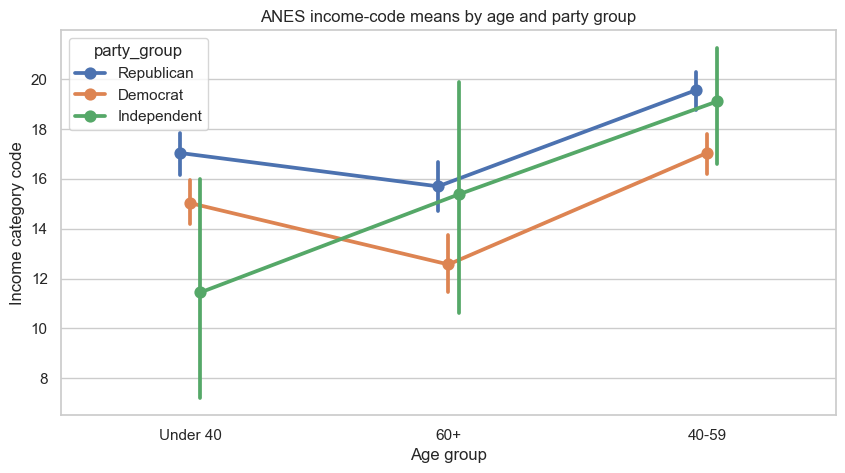

,party_group,age_group,income_code
0,Democrat,40-59,17.0317
1,Democrat,60+,12.5648
2,Democrat,Under 40,15.0262
3,Independent,40-59,19.1000
4,Independent,60+,15.3750
5,Independent,Under 40,11.4444
6,Republican,40-59,19.5586
7,Republican,60+,15.6952
8,Republican,Under 40,17.0355


In [3]:
means = factorial.groupby(["party_group", "age_group"], observed=True,
                           as_index=False)["income_code"].mean()
fig, ax = plt.subplots()
sns.pointplot(data=factorial, x="age_group", y="income_code", hue="party_group",
              errorbar=("ci", 95), dodge=.08, ax=ax)
ax.set(title="ANES income-code means by age and party group",
       xlabel="Age group", ylabel="Income category code")
plt.show()
means


## 7.2 ANCOVA

The ANES ANCOVA models weekly TV-news viewing by expected vote while adjusting for age. Because ANES is observational,
the adjusted coefficient is an association, not a treatment effect. The group-by-age interaction checks whether a common
age slope is reasonable before fitting the simpler adjusted model.


In [4]:
ancova_df = anes[["expected_vote", "age_years", "tv_news_days_per_week"]].dropna()
slope_check = ols("tv_news_days_per_week ~ age_years * C(expected_vote)", data=ancova_df).fit()
adjusted = ols("tv_news_days_per_week ~ age_years + C(expected_vote)", data=ancova_df).fit()
print("Slope-homogeneity model:")
display(anova_lm(slope_check, typ=2))
print()
print("Adjusted observational model coefficients:")
display(adjusted.summary2().tables[1])


Slope-homogeneity model:


,sum_sq,df,F,PR(>F)
C(expected_vote),8.9815,1.0,1.5022,2.2064e-01
age_years,1137.0332,1.0,190.1710,1.5572e-39
age_years:C(expected_vote),0.3210,1.0,0.0537,8.1681e-01
Residual,5620.2650,940.0,NaN,NaN



Adjusted observational model coefficients:


,Coef.,Std.Err.,t,P>|t|,[0.025,0.975]
Intercept,0.6603,0.2476,2.6665,7.7971e-03,0.1743,1.1463
C(expected_vote)[T.Dole],-0.1982,0.1616,-1.2262,2.2041e-01,-0.5153,0.1190
age_years,0.0670,0.0049,13.7972,1.4259e-39,0.0574,0.0765


## Worked example and interpretation

### Factorial model

The first ANES model treats income-category code as a numeric teaching outcome and includes party group, age group, and their interaction. Party and age group have strong overall associations with the coded outcome (F = 21.59 and 39.48), while the interaction test gives F = 1.94 and p = 0.102. The cell-mean plot lets the reader inspect how each party group's profile changes across ages; visual differences between lines are not themselves an interaction test. Because income is recorded as ordered categories, a one-unit change in its code is **not** a one-unit monetary change. This linear model is exploratory and depends on how the coding is interpreted.

### Adjusted model

The ANCOVA example instead models weekly TV-news days using respondent age and expected vote. An age-by-vote interaction check gives p = 0.817, so this sample does not show clear evidence that the fitted age slope differs by vote group. In the simpler common-slope model, the estimated age coefficient is 0.067 additional TV-news days per week for each year of age, conditional on vote group. The adjusted Dole-versus-Clinton coefficient is −0.198 with p = 0.220. These are conditional **associations** in survey data, not causal effects of age or vote choice; inspect fit and residuals before using the linear approximation for prediction.

## Practice and solution

**Practice.** In a treatment-by-sex model, the interaction p-value is .01. What should be reported next?

<details><summary>Solution</summary>

Report estimated treatment effects within each sex (simple effects) with confidence intervals and a
multiplicity plan, plus an interaction plot. Avoid summarizing the result only with the overall
treatment main effect because it averages across meaningfully different effects.
</details>

## Key takeaways

- Interactions change the meaning of main effects.
- ANCOVA can improve precision when covariates are pre-treatment and appropriately modeled.
- Model diagnostics and study design remain essential; an ANOVA table does not establish causality.


## Reproducibility checklist

- State the population, outcome, groups, and sampling unit.
- State $H_0$, $H_1$, alpha, and whether the test is one- or two-sided before looking at results.
- Verify independence from the design; use plots and diagnostics for distributional assumptions.
- Report the estimate, confidence interval, effect size, test statistic, degrees of freedom, and exact p-value.
- Separate statistical evidence from practical importance and acknowledge design limitations.
